# Data Science in Psychology and Neuroscience

## Class info:
* Week #8
* Day: March 12, 2026
* Time: 9:30—10:45 AM
* Location: Logan Hall 125
* <a href="https://forms.microsoft.com/r/26vAcJWrwH">Click here to submit your attendance for Week 8, Question 16!</a>
  
## Instructor info:
* Dr. Jeremy Hogeveen
* jhogeveen@unm.edu
* Logan Hall 281 (Office Hours By Appointment)
  
## Syllabus:
* <a href="https://www.dropbox.com/scl/fi/6fs6fi4kvkwtxn7j7x8ua/PSY450650_DSPN_Spring2026_Syllabus.pdf?rlkey=148e5t4ah8q2n1daclt7mp0h6&dl=0">Download here</a>

## Today's topic:
0. <a href="https://github.com/JeremyHogeveen/dspn_spring2026_github/blob/main/code/dspn_spring2026_week7_03052026.ipynb">Refresher of last week</a>, and update on assignment #4 deadline (now due: <a href="https://www.dropbox.com/request/NztxpcILddttMXejRRb9">March 23, 2026 after Spring Break</a>).
1. A few remaining ggplot2 tips:
    * Spotting outliers / influential observations with `geom_label`
    * Aggregating data with `stat_summary` layers
2. Some suggestions for effective data visualization

# Section 1: Spotting outliers and/or influential observations.

* Our inferential or predictive models often rely on aggregate
    * i.e., central tendency and variance measures.
* We visualize individual data points for a reason.
    * Can help us to identify __outliers__ and __influential observations__.
    * __Outliers__: Data points that are wayyy off the beaten path.
    * __Influential Observations__: Data points that exert undue influence on our models.
<img src="img/outlier.png" width=200>
<img src="img/influential_observation.png" width=200>

* A standard scatter plot can tell you if an outlier or inf obs exists, but cannot tell you which case it is.
    * For this, I use `geom_label`

In [4]:
library(tidyverse)

# let's use the 'mpg' dataset and look for cars with high highway mileage
df <- mpg %>%
    mutate(outlier_label = ifelse(hwy > 40,
                                  as.character(model),
                                  NA))

print(df %>% filter(outlier_label!="NA") %>% select(model,year))

# A tibble: 3 × 2
  model       year
  <chr>      <int>
1 jetta       1999
2 new beetle  1999
3 new beetle  1999


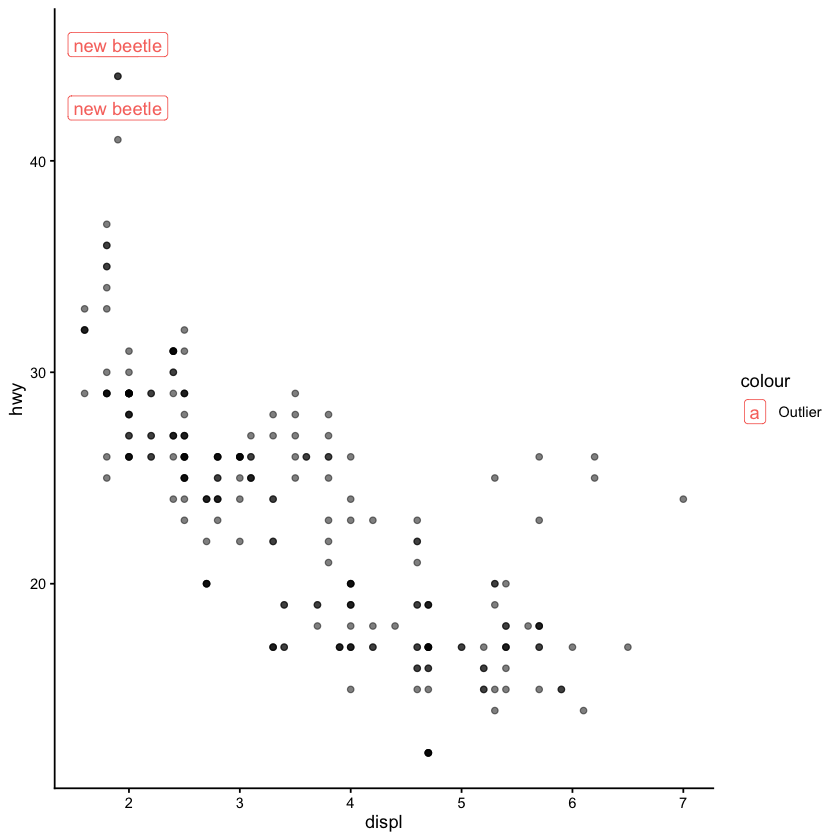

In [18]:
# now let's identify outliers on a scatterr plot between displ and hwy mileage
plot_labels <- ggplot(df, aes(x = displ, y = hwy)) +
    geom_point(alpha=0.5) +
    geom_label(aes(label = outlier_label, color="Outlier"),
               na.rm = TRUE,
              nudge_y = 1.5) +
    theme_classic()
plot_labels

# A tibble: 2 × 2
  model            year
  <chr>           <int>
1 corvette         2008
2 k1500 tahoe 4wd  1999


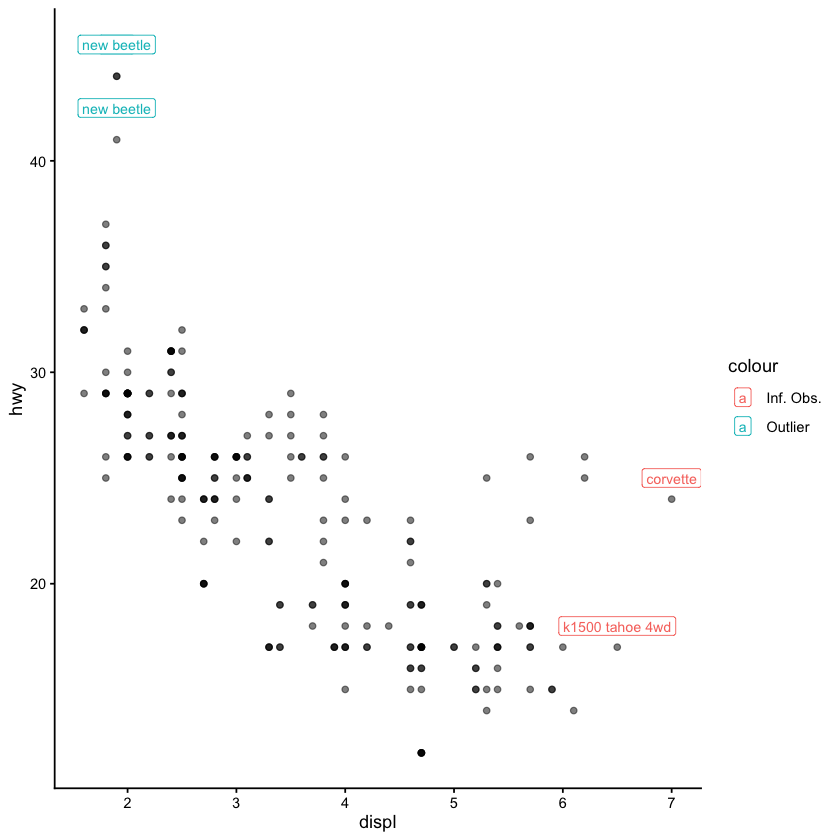

In [32]:
# add in influential observations and present them in a differetn color
mod <- lm(hwy ~ displ, df)
hat_vals <- hatvalues(mod)
df <- df %>%
    mutate(inf_obs = ifelse(hat_vals > (3 * mean(hat_vals)),
                            as.character(model),
                            NA))
print(df %>% filter(inf_obs!="NA") %>% select(model,year))

plot_labels <- ggplot(df, aes(x = displ, y = hwy)) +
    geom_point(alpha=0.5) +
    geom_label(aes(label = outlier_label, color="Outlier"),
               na.rm = TRUE,
              nudge_y = 1.5,   
               size = 3) + 
    geom_label(aes(label = inf_obs, color="Inf. Obs."), 
               na.rm = TRUE,
               nudge_y = 1,   
               size = 3) +
    theme_classic()

plot_labels

# Section 2: Aggregated data visuals.

* `lm`, `t.test`, `aov` etc. are based on central tendencies and spread in your data.
    * Sometimes, plotting jitter boxplots or other distributional data visualizations can occlude what is truly driving the effect.
    * Makes the results harder for a human to interpret.
* `stat_summary` is a useful way to plot the aggregated data directly that nicely complements inferential model outputs.

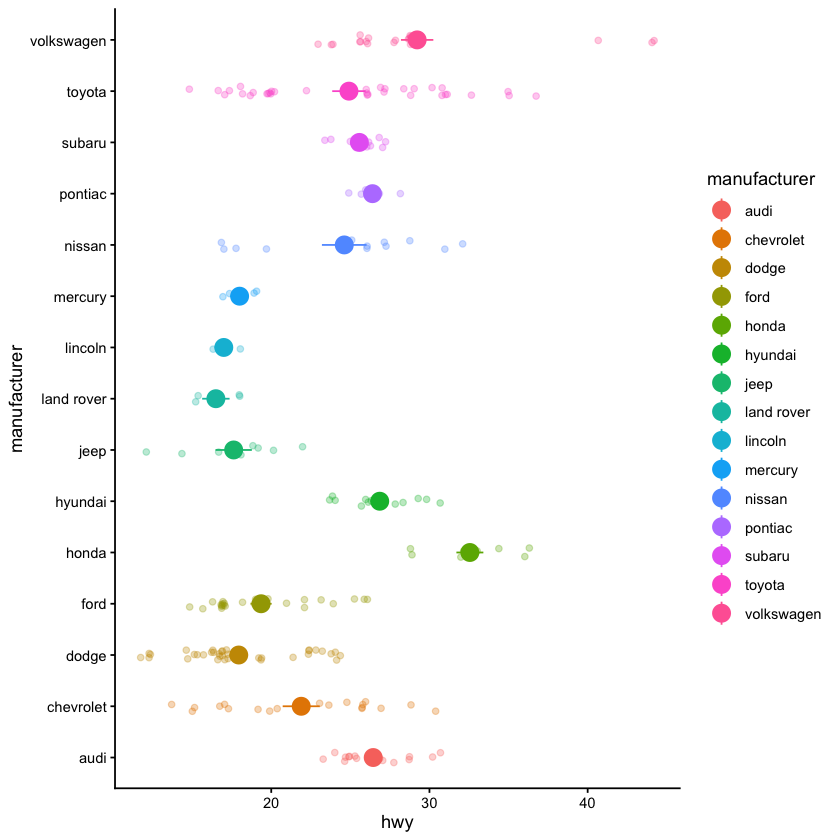

In [39]:
plot_aggregatae <- ggplot(df,aes(x = manufacturer, y = hwy, color = manufacturer)) +
    geom_jitter(width = 0.1,alpha = 0.3) +
    stat_summary(fun.data = mean_se,
                geom = "pointrange",
                size = 1) +
    theme_classic() + 
    # theme(axis.text.x = element_text(angle = 45, hjust = 1))
    coord_flip()
plot_aggregatae

# Section 3: General suggestions for effective data visualization.

1. Imagine you are going to print it off.
    * Heavy on information, light on ink usage!

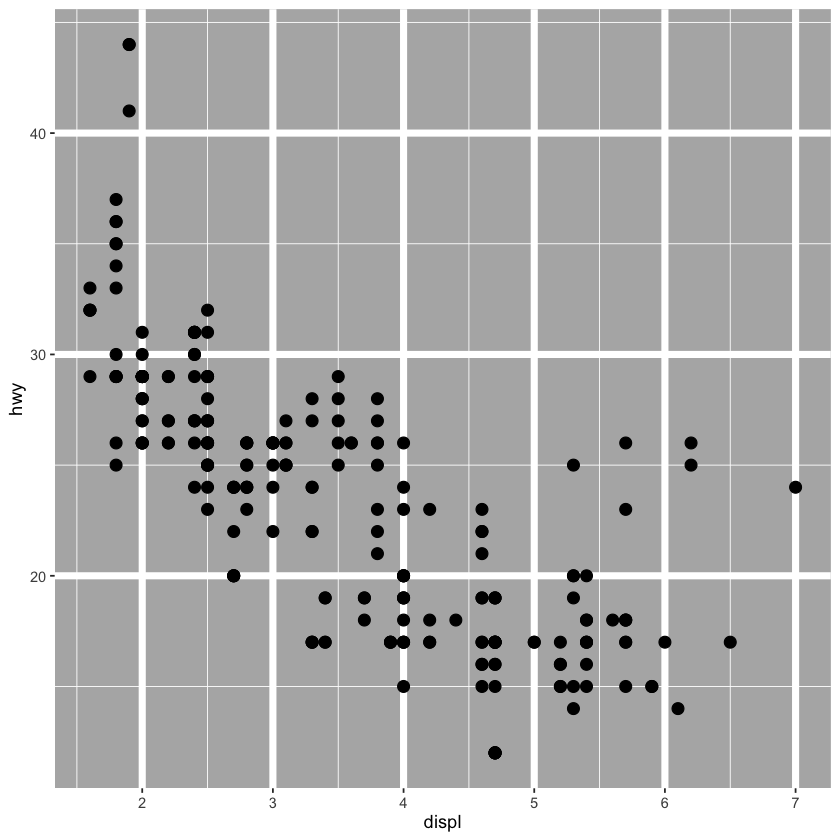

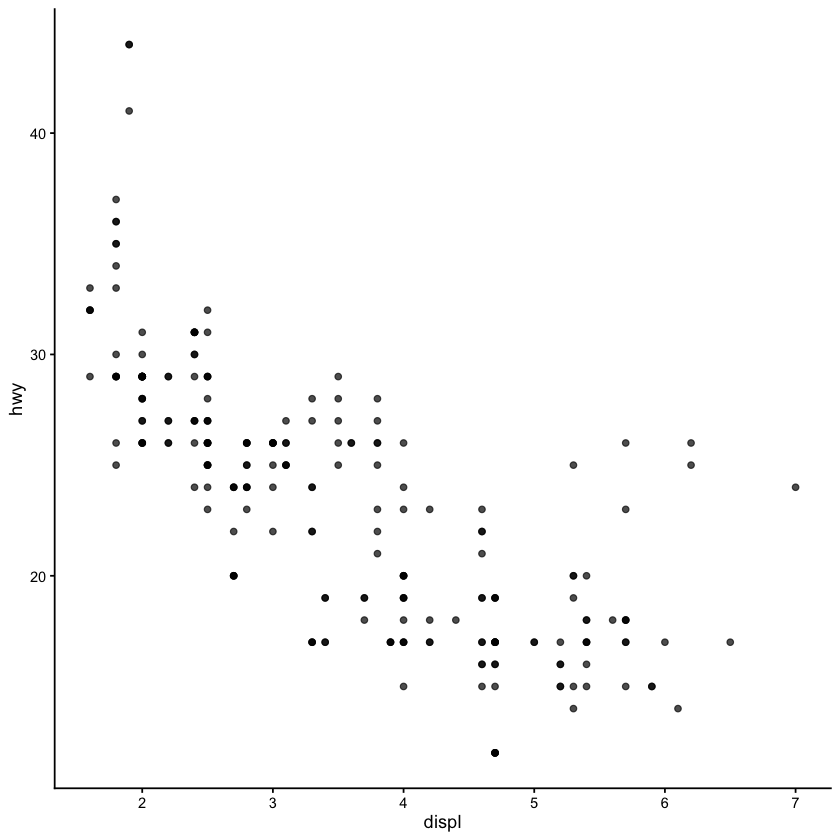

In [41]:
plot_darkgrey <- ggplot(mpg, aes(x = displ, y = hwy)) + 
  geom_point(size = 3) + 
  theme(panel.background = element_rect(fill = "gray70"), 
        panel.grid.major = element_line(linewidth = 2, color = "white"))
plot_darkgrey

plot_whitebackground <- ggplot(mpg, aes(x = displ, y = hwy)) + 
  geom_point(alpha = 0.7) + 
  theme_classic()
plot_whitebackground

2. Look at the raw data.
    * Aggregated data can be fine, sometimes, but you better have looked at distributions and individual data points at some point! 

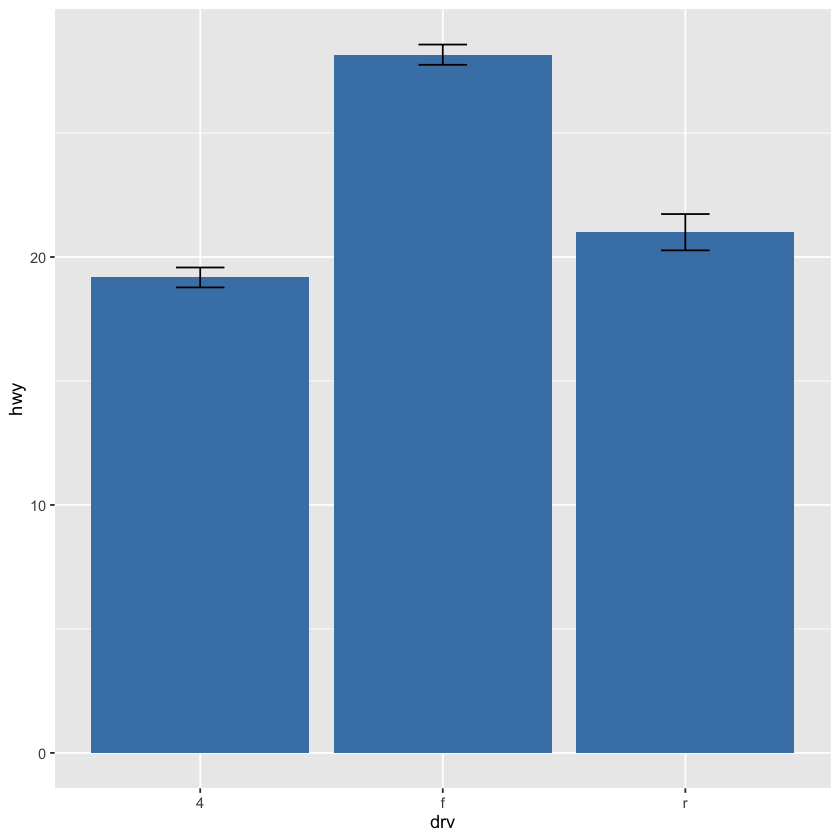

In [42]:
ggplot(mpg, aes(x = drv, y = hwy)) + 
  stat_summary(fun = mean, geom = "bar", fill = "steelblue") +
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.2)

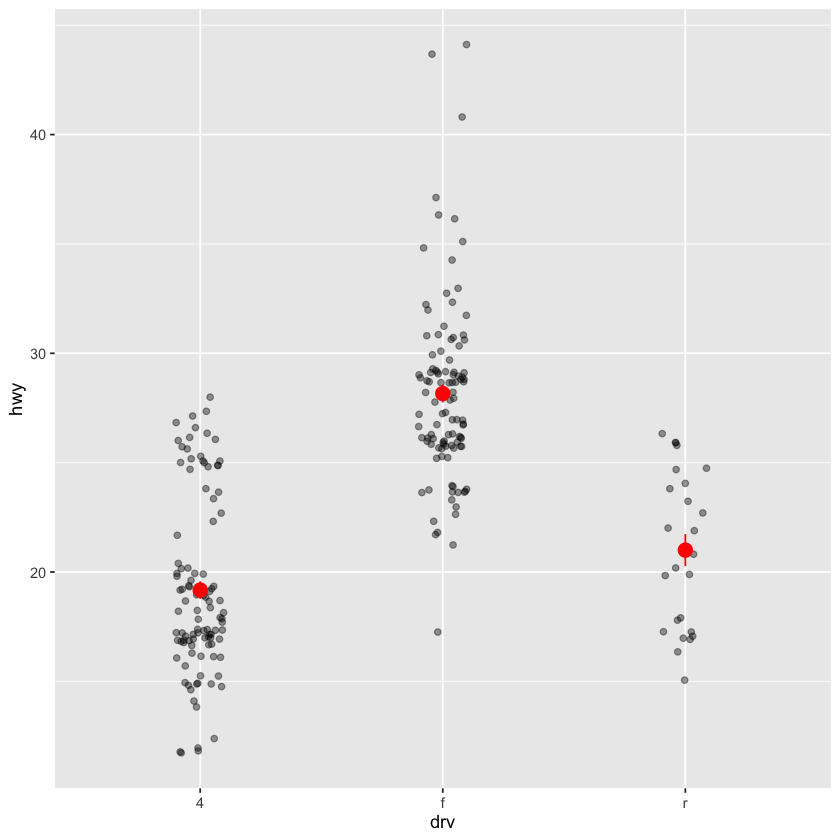

In [43]:
ggplot(mpg, aes(x = drv, y = hwy)) + 
  geom_jitter(width = 0.1, alpha = 0.4) +
  stat_summary(fun.data = mean_se, geom = "pointrange", color = "red", size = 0.75)

3. Accessibility matters!
    * More folks than you might realize have color vision deficiency. Avoid standard red / green contrasts, use colorblind-friendly palettes.

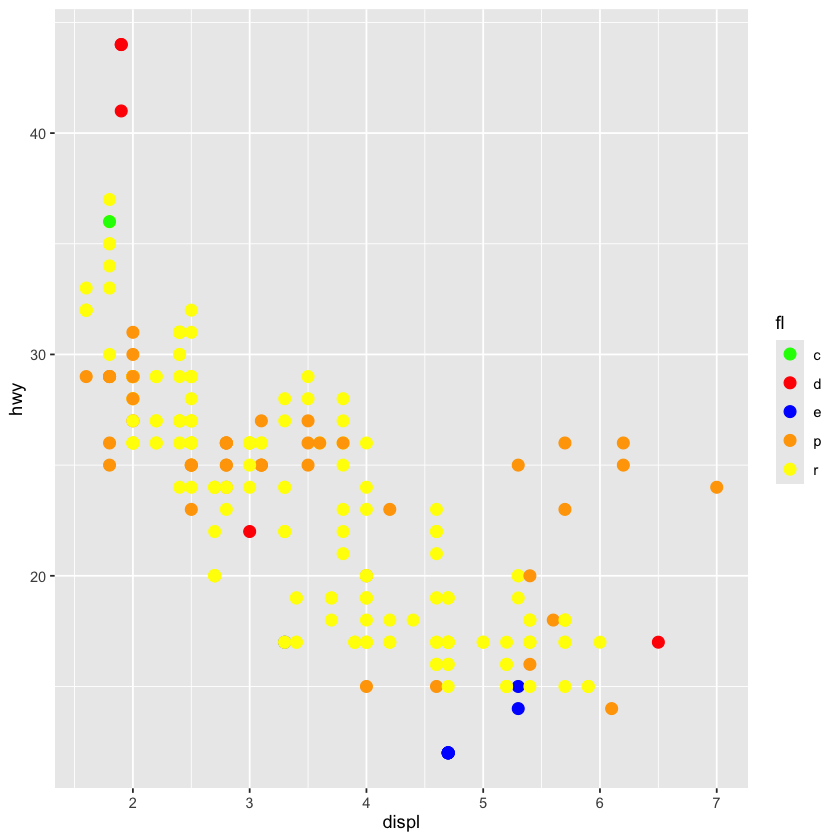

In [44]:
# color blind issue plot
ggplot(mpg, aes(x = displ, y = hwy, color = fl)) + 
  geom_point(size = 3) +
  scale_color_manual(values = c("green", "red", "blue", "orange", "yellow"))

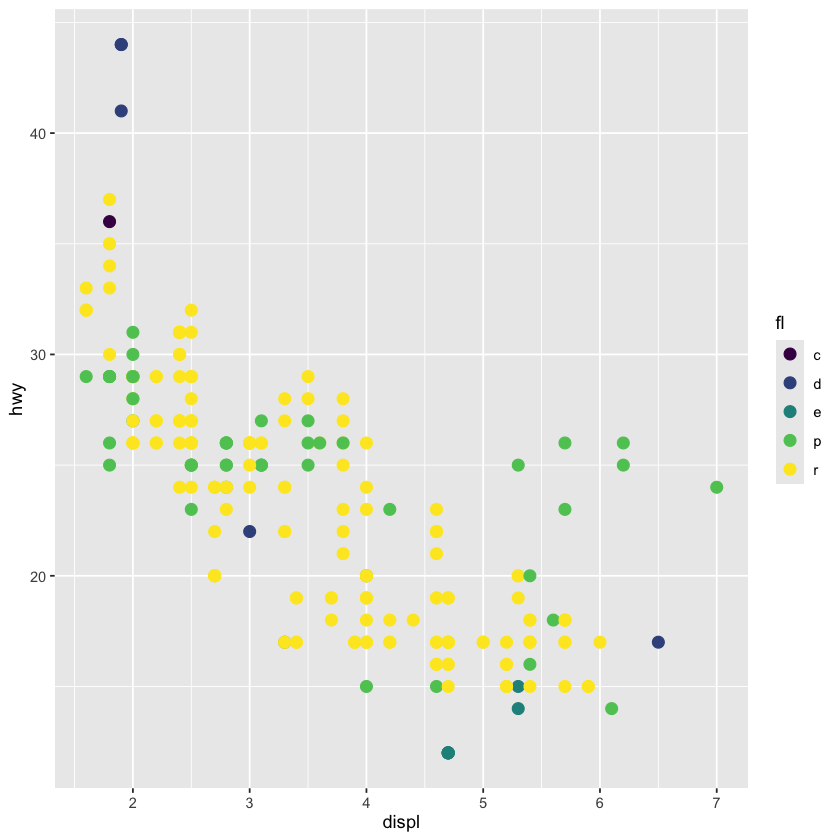

In [45]:
# color blind accessible plot
ggplot(mpg, aes(x = displ, y = hwy, color = fl)) + 
  geom_point(size = 3) +
  scale_color_viridis_d() # _d for discrete, _c for continuous

4. Honest axes.
    * Don't arbitrarily truncate axes to make small effects look bigger.

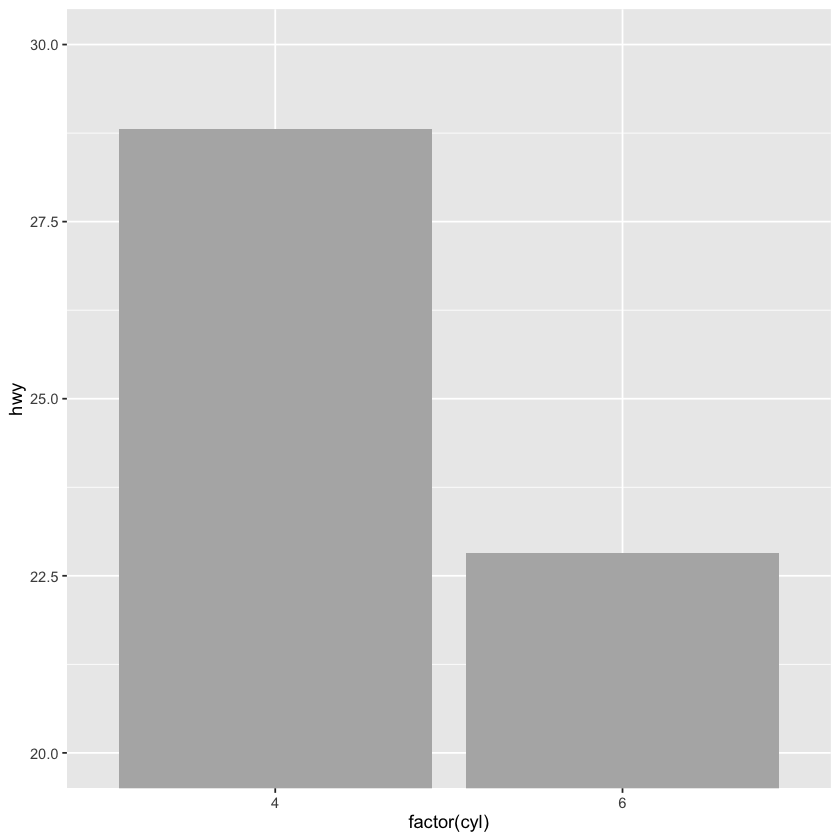

In [46]:
# truncated hwy mpg plot
mpg_sub <- mpg %>% filter(cyl %in% c(4, 6))

ggplot(mpg_sub, aes(x = factor(cyl), y = hwy)) + 
  stat_summary(fun = mean, geom = "bar", fill = "gray70") +
  coord_cartesian(ylim = c(20, 30))

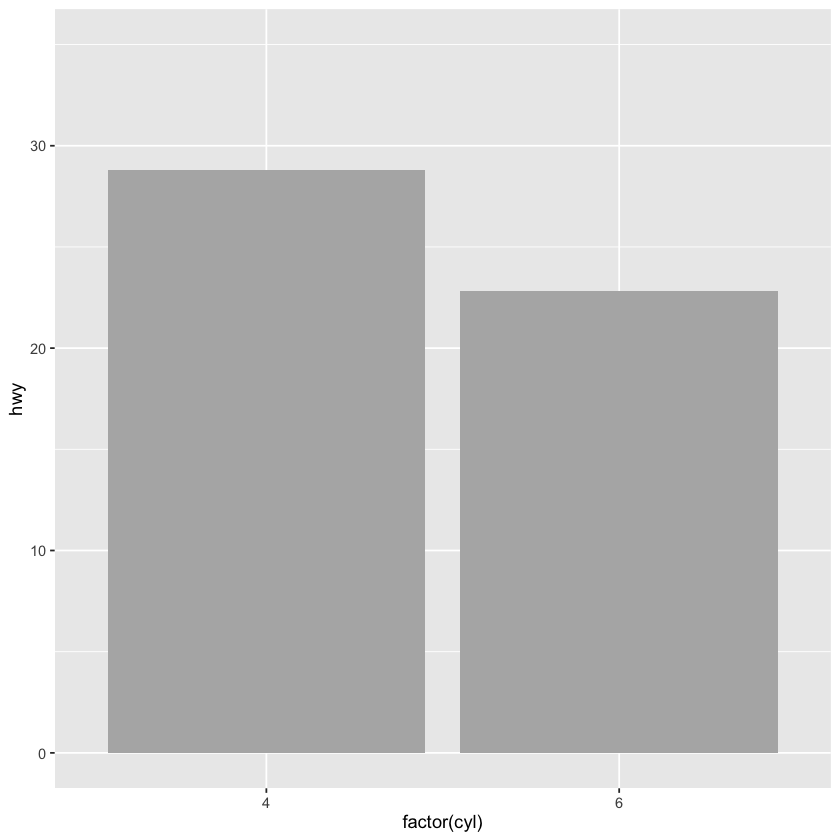

In [47]:
# full hwy mpg plot
ggplot(mpg_sub, aes(x = factor(cyl), y = hwy)) + 
  stat_summary(fun = mean, geom = "bar", fill = "gray70") +
  coord_cartesian(ylim = c(0, 35))

5. Clear, descriptive figure annotations.
    * Axes, legends, etc. should contain human-readable labels.

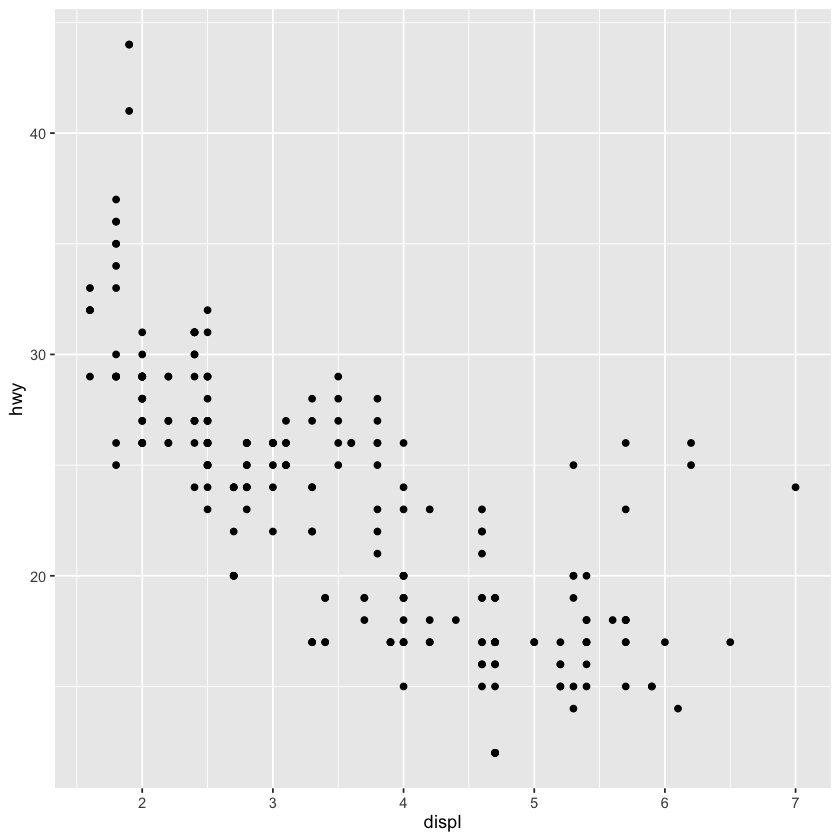

In [48]:
ggplot(mpg, aes(x = displ, y = hwy)) + 
  geom_point()

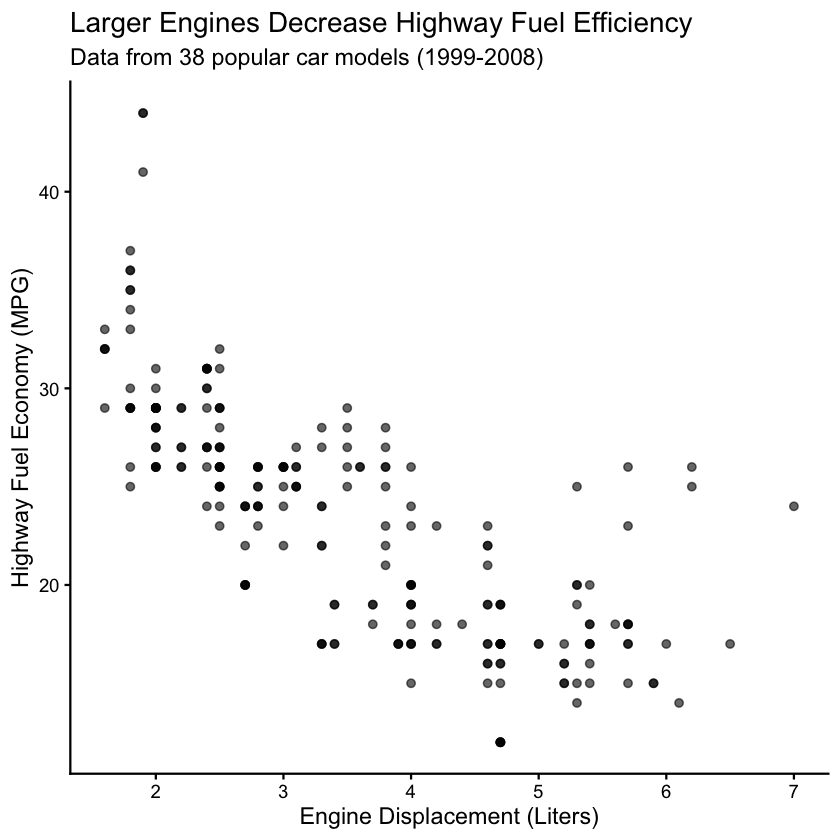

In [52]:
ggplot(mpg, aes(x = displ, y = hwy)) + 
  geom_point(alpha = 0.6) +
  labs(title = "Larger Engines Decrease Highway Fuel Efficiency",
       subtitle = "Data from 38 popular car models (1999-2008)",
       x = "Engine Displacement (Liters)",
       y = "Highway Fuel Economy (MPG)") +
  theme_classic(base_size=14)

# Introducing assignment 4!
* <a href="https://github.com/JeremyHogeveen/dspn_spring2026_github/tree/main/assignment_materials/Assignment_4">link to materials</a>